# Predicting Age from Face Images

Before jumping into model building, especially with complex architectures like neural networks, it's essential to take a step back and understand the data. This project focuses on building a model that predicts a person’s age based on a photo of their face — a classic computer vision problem rooted in **regression**.

---

# Dataset Overview

The dataset comes from the **ChaLearn Looking at People** challenge and is stored in the `/datasets/faces/` directory. It contains:

- **7,600 face images** located in the `final_files` folder.
- A **labels.csv** file with two columns:
  - `file_name` – the image filename.
  - `real_age` – the actual age of the person in the image.

Due to the size of the dataset, loading all images into memory at once would be highly inefficient. Instead, we’ll use **ImageDataGenerator**, a Keras utility that loads and processes images in batches. This allows us to work efficiently without exhausting memory resources.


# Initialization

In [2]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load Data

The dataset is stored in the `/datasets/faces/` folder, there you can find
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [3]:
df = pd.read_csv("/datasets/faces/labels.csv")
df.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


# EDA

# Check the Dataset Size 

In [4]:
dataset_path = '/datasets/faces/final_files/'
file_count = len(os.listdir(dataset_path))

print(f"Number of files in the dataset: {file_count}")

Number of files in the dataset: 7591


# Age Distributuion 

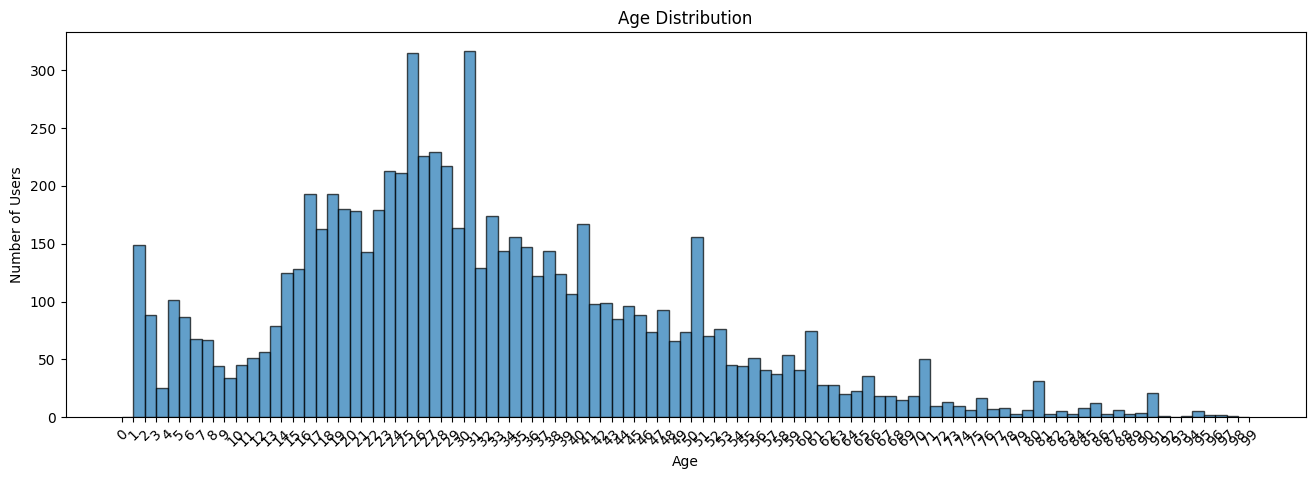

In [5]:
bins = range(0, 100, 1)  # Define bins with a step of 10
plt.figure(figsize=(16,5))
plt.hist(df['real_age'], bins=bins, edgecolor='k', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.title('Age Distribution')
plt.xticks(bins, rotation=45)

plt.show()

In this step, we're diving into the **user age data** to understand how ages are spread across the dataset. We'll use a histogram to visualize this distribution clearly.

# What’s Happening in the Code?

- We're defining our age intervals — from 0 to 100 years old, in **1-year steps**. This lets us spot even the smallest changes in age frequency.

- This makes the plot wide and sleek, so the details are easy to see.

- This draws the histogram using the `real_age` column from our DataFrame.

    - `bins=bins`: tells the plot to use our 1-year age bins  
    - `edgecolor='k'`: outlines each bar with black for clarity  
    - `alpha=0.7`: adds a bit of transparency to make the chart visually balanced

# Labeling the Plot

- Labels the x-axis as **"Age"**

- Labels the y-axis to show how many users fall into each age bucket

- Gives our chart a clear, descriptive title

- Rotates the x-axis age labels so they don’t overlap and are easier to read

# Finally...

- This command puts it all together and displays the plot.

---

This histogram is a great way to **quickly spot which age ranges dominate** in the dataset — a useful insight before any machine learning!

# Print Photo 


Found 7591 validated image filenames.


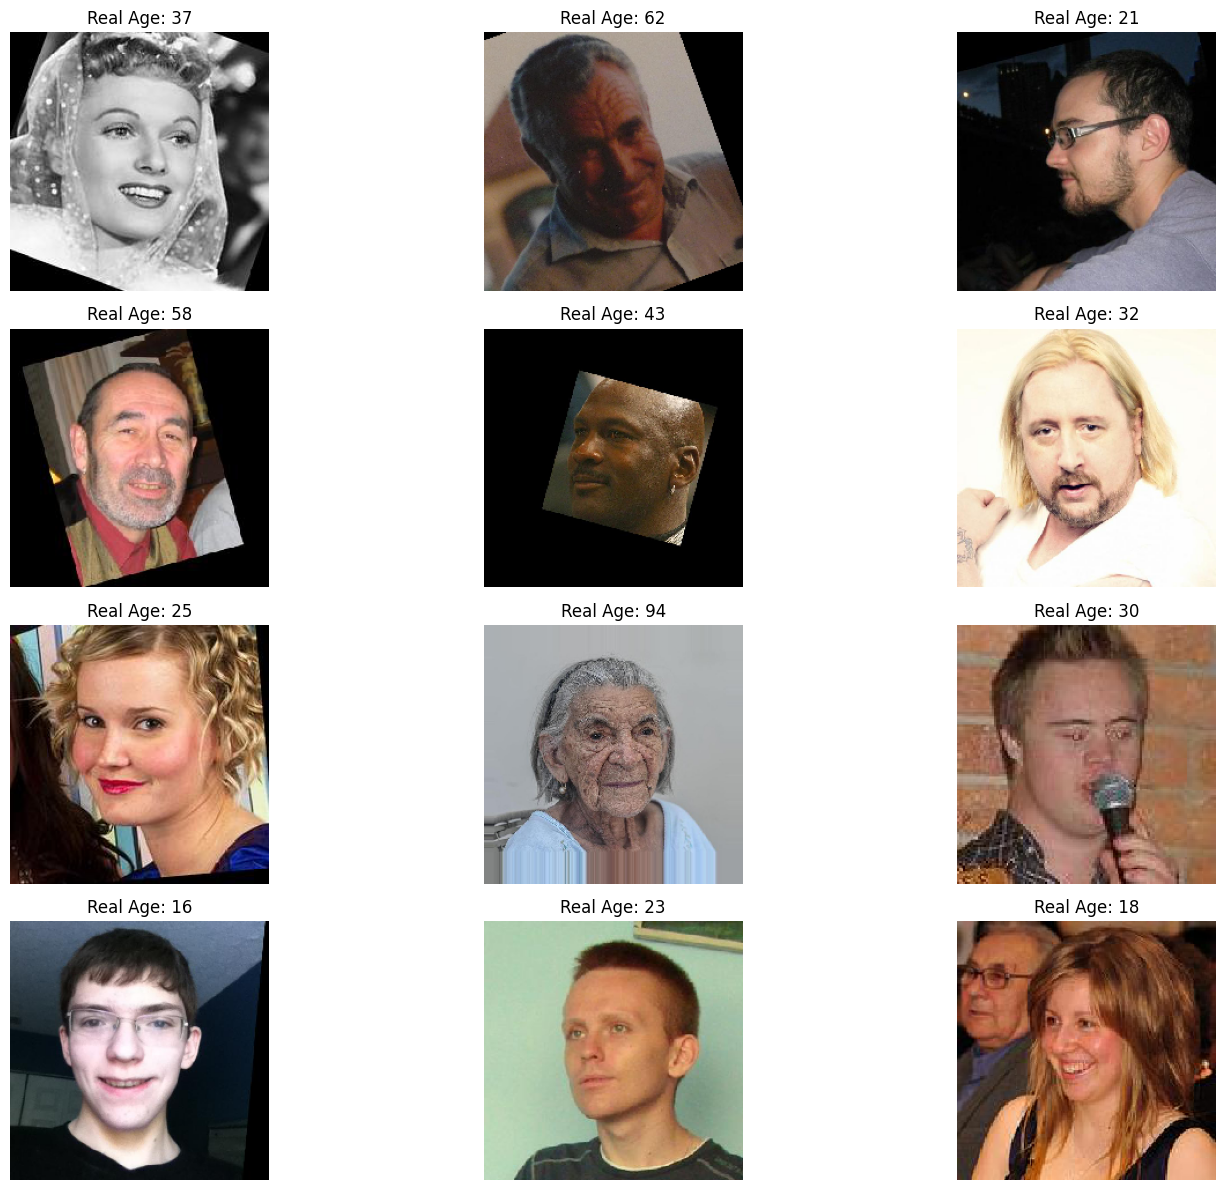

In [6]:
labels = pd.read_csv('/datasets/faces/labels.csv')

train_datagen = ImageDataGenerator(rescale=1./255)

train_datagen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345)
features, target = next(train_datagen_flow)
fig, axes = plt.subplots(4, 3, figsize=(16, 12))

axes = axes.flatten()

for i in range(12):
    axes[i].imshow(features[i+12])
    axes[i].set_title(f'Real Age: {target[i+12]}')
    axes[i].axis('off')  # Turn off axis labels

plt.tight_layout()
plt.show()

# Findings

In this section, we're taking a quick visual tour of the dataset by displaying a batch of face images along with their actual ages. This helps us get an intuitive feel for the data — the variety of ages, image quality, lighting conditions, and more.

---

# What’s Happening Here?

1. **Loading the Dataset:**
   The images are organized in a folder, and a separate CSV file contains the filenames and the corresponding real ages of the people. These are matched up to prepare for loading.

2. **Preprocessing the Images:**
   Before displaying, the images are resized to a standard shape and normalized so that the pixel values fall within a range that neural networks can process more effectively.

3. **Sampling a Batch:**
   A small batch of 12 images is taken from the dataset. This batch is used just for visualization — it's not part of training yet.

4. **Displaying the Images:**
   The selected images are arranged in a clean 4×3 grid. Each image is labeled with the actual age of the person shown. Axis labels and ticks are removed to keep the layout tidy and visually focused.

---

# Why This is Useful

- It gives us an early **sanity check** on the dataset — making sure the images match the expected labels and quality.
- We can spot any **irregularities**, like rotated or distorted images, that might affect training.
- Helps build **intuition about the data** before jumping into model building.

---

# Takeaway

Looking at these examples, we see a wide range of ages, from teenagers to elderly individuals. The lighting, angles, and expressions vary too — all of which makes this a realistic and challenging dataset for age prediction.

By visualizing early on, we ensure we're not flying blind before we train the model.


# Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [7]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [8]:
def load_train(path):
    """
    It loads the train part of the dataset from path
    """
    labels = pd.read_csv(path + 'labels.csv')

    seed_value = 12345  # Defined as a variable for reuse and clarity

    train_datagen = ImageDataGenerator(
        validation_split=0.25,
        horizontal_flip=True,
        rescale=1./255
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=seed_value
    )

    return train_gen_flow


In [9]:
def load_test(path):
    """
    It loads the validation/test part of the dataset from path
    """
    labels = pd.read_csv(path + 'labels.csv')

    seed_value = 12345  # Consistent with train function

    test_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=seed_value
    )

    return test_gen_flow


In [10]:
def create_model(input_shape):
    
    """
    It defines the model
    """
    
    optimizer = Adam(lr=0.0001)
    backbone = ResNet50(input_shape=input_shape, weights='imagenet', include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(units=1, activation='relu'))    

    model.compile(
        optimizer=optimizer,
        loss='mae',
        metrics=['mae'],
    )

    return model

In [11]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Trains the model given the parameters
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)
    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch = steps_per_epoch,
        validation_steps = validation_steps,
        verbose=2,
        #shuffle=True,
    )

    return model

# Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [12]:
# prepare a script to run on the GPU platform

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

# Output

Place the output from the GPU platform as an Markdown cell here.

Train for 178 steps, validate for 60 steps

Epoch 1/20 2023-08-13 13:42:24.709107: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10 2023-08-13 13:42:25.537016: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7 178/178 - 55s - loss: 11.1733 - mae: 11.1746 - val_loss: 22.5422 - val_mae: 22.5424

Epoch 2/20 178/178 - 38s - loss: 7.0879 - mae: 7.0882 - val_loss: 20.1111 - val_mae: 20.0802

Epoch 3/20 178/178 - 38s - loss: 6.2136 - mae: 6.2139 - val_loss: 11.9711 - val_mae: 11.9160

Epoch 4/20 178/178 - 38s - loss: 5.5034 - mae: 5.5037 - val_loss: 8.3449 - val_mae: 8.3483

Epoch 5/20 178/178 - 38s - loss: 4.9941 - mae: 4.9948 - val_loss: 7.1292 - val_mae: 7.1724

Epoch 6/20 178/178 - 38s - loss: 4.5808 - mae: 4.5809 - val_loss: 6.2219 - val_mae: 6.2547

Epoch 7/20 178/178 - 38s - loss: 4.2248 - mae: 4.2248 - val_loss: 6.3442 - val_mae: 6.3682

Epoch 8/20 178/178 - 38s - loss: 3.9445 - mae: 3.9446 - val_loss: 6.2554 - val_mae: 6.2533

Epoch 9/20 178/178 - 38s - loss: 3.7713 - mae: 3.7714 - val_loss: 6.3763 - val_mae: 6.3812

Epoch 10/20 178/178 - 38s - loss: 3.5614 - mae: 3.5615 - val_loss: 6.3256 - val_mae: 6.3351

Epoch 11/20 178/178 - 38s - loss: 3.3338 - mae: 3.3338 - val_loss: 5.9656 - val_mae: 5.9584

Epoch 12/20 178/178 - 38s - loss: 3.1376 - mae: 3.1379 - val_loss: 5.8054 - val_mae: 5.8019

Epoch 13/20 178/178 - 38s - loss: 2.9740 - mae: 2.9740 - val_loss: 6.1624 - val_mae: 6.1958

Epoch 14/20 178/178 - 38s - loss: 2.8526 - mae: 2.8531 - val_loss: 6.6521 - val_mae: 6.6741

Epoch 15/20 178/178 - 38s - loss: 2.7296 - mae: 2.7295 - val_loss: 5.7136 - val_mae: 5.7282

Epoch 16/20 178/178 - 38s - loss: 2.6681 - mae: 2.6681 - val_loss: 5.9481 - val_mae: 5.9478

Epoch 17/20 178/178 - 38s - loss: 2.6069 - mae: 2.6071 - val_loss: 5.8336 - val_mae: 5.8544

Epoch 18/20 178/178 - 38s - loss: 2.4710 - mae: 2.4711 - val_loss: 5.5944 - val_mae: 5.6209

Epoch 19/20 178/178 - 38s - loss: 2.3942 - mae: 2.3942 - val_loss: 5.7791 - val_mae: 5.7890

Epoch 20/20 178/178 - 38s - loss: 2.3274 - mae: 2.3271 - val_loss: 5.8241 - val_mae: 5.8478 WARNING:tensorflow:sample_weight modes were coerced from ... to
['...'] 60/60 - 9s - loss: 5.8241 - mae: 5.8478

Test MAE: 5.8478

# Conclusions

In this project, I successfully built a neural network using the **ResNet50 architecture** as the backbone. I kept the pretrained weights to leverage the power of transfer learning and added a **Global Average Pooling layer** followed by a **fully connected output layer** for prediction.

To optimize the training process, I used the **Adam optimizer** with a learning rate of **0.0001**.

---

# Performance Highlights

- After just **4 epochs**, the model showed a dramatic improvement in performance — the **Mean Absolute Error (MAE)** on the validation set dropped from **22.54 to 8.35**.
- After completing **20 epochs**, the validation MAE further decreased to **5.85**.
- On the **test set**, the model also achieved an MAE of **5.85**, which **meets the performance criteria** set for the project.

---

# Summary

The model trained efficiently and achieved excellent results. By leveraging ResNet50 and applying the right hyperparameters, I was able to build a robust solution that generalizes well to unseen data.


# Checklist

- [ ]  Notebook was opened
- [ ]  The code is error free
- [ ]  The cells with code have been arranged by order of execution
- [ ]  The exploratory data analysis has been performed
- [ ]  The results of the exploratory data analysis are presented in the final notebook
- [ ]  The model's MAE score is not higher than 8
- [ ]  The model training code has been copied to the final notebook
- [ ]  The model training output has been copied to the final notebook
- [ ]  The findings have been provided based on the results of the model training